# Fitness Classification — Experiment Notebook

Notebook này trình bày toàn bộ quy trình thực nghiệm theo 4 giai đoạn:

| Giai đoạn | Nội dung |
|---|---|
| **1** | Chuẩn bị dữ liệu & Feature Engineering (BMI) |
| **2** | Baseline — 3 mô hình trên **dữ liệu thô** (không tuning) |
| **3** | So sánh — 3 mô hình trên **dữ liệu có Feature Engineering** (không tuning) |
| **4** | Tinh chỉnh tham số — **GridSearchCV + StratifiedKFold** trên dữ liệu FE |

> **Mục tiêu dự đoán:** `is_fit` (0 = không fit, 1 = fit)  
> **Metric chính:** Recall (class 0), Precision, F1, Accuracy

---
## 0. Import thư viện

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score,
    make_scorer
)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print('✅ Import hoàn tất')

✅ Import hoàn tất


---
## 1. Chuẩn bị dữ liệu

### 1.1 Load dữ liệu

In [24]:
URL = "https://raw.githubusercontent.com/hoangminh125HY/data_ML_isfit/refs/heads/master/data/fitness_dataset.csv"
df = pd.read_csv(URL)

print(f'Shape: {df.shape}')
print(f'Target distribution:\n{df["is_fit"].value_counts(normalize=True).round(3)}')
df.head()

Shape: (2000, 11)
Target distribution:
is_fit
0    0.6
1    0.4
Name: proportion, dtype: float64


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [25]:
print('=== Thông tin tổng quát ===')
df.info()
print('\n=== Missing values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Thống kê mô tả ===')
df.describe().round(2)

=== Thông tin tổng quát ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB

=== Missing values ===
sleep_hours    160
dtype: int64

=== Thống kê mô tả ===


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,is_fit
count,2000.00,2000.00,2000.00,2000.00,2000.00,1840.00,2000.00,2000.00,2000.00
mean,49.11,174.53,83.54,70.29,119.91,7.51,5.04,3.00,0.40
std,17.93,14.37,25.85,11.85,14.58,1.50,2.86,1.14,0.49
min,18.00,150.00,30.00,45.00,90.00,4.00,0.00,1.00,0.00
25%,34.00,162.00,64.00,62.10,109.70,6.50,2.55,2.04,0.00
50%,49.00,174.00,83.00,70.25,120.00,7.50,5.06,2.98,0.00
75%,65.00,187.00,102.00,78.43,129.80,8.60,7.47,3.95,1.00
max,79.00,199.00,250.00,118.60,171.20,12.00,10.00,4.99,1.00


### 1.1b Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra phân phối nhãn, missing values, outliers và mixed types trước khi đưa vào pipeline.

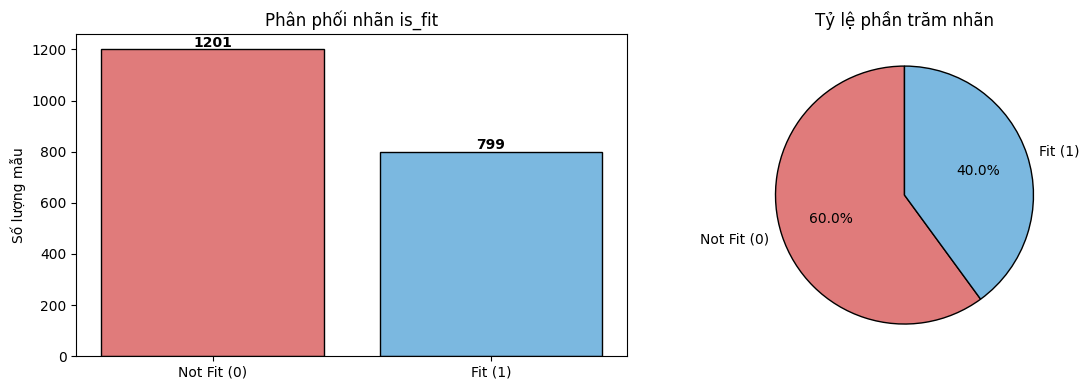

Fit : Not Fit = 799 : 1201  (ratio = 0.67)
=> Dataset mất cân bằng — cần chú ý Recall


In [26]:
# ── 1. Phân phối nhãn (class imbalance) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['is_fit'].value_counts()
axes[0].bar(['Not Fit (0)', 'Fit (1)'], label_counts.values,
            color=['#e07b7b', '#7bb8e0'], edgecolor='k')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Phân phối nhãn is_fit')
axes[0].set_ylabel('Số lượng mẫu')

axes[1].pie(label_counts.values, labels=['Not Fit (0)', 'Fit (1)'],
            autopct='%1.1f%%', colors=['#e07b7b', '#7bb8e0'],
            startangle=90, wedgeprops={'edgecolor': 'k'})
axes[1].set_title('Tỷ lệ phần trăm nhãn')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = label_counts[1] / label_counts[0]
print(f'Fit : Not Fit = {label_counts[1]} : {label_counts[0]}  (ratio = {ratio:.2f})')
print('=> Dataset tương đối cân bằng' if 0.7 < ratio < 1.4 else '=> Dataset mất cân bằng — cần chú ý Recall')


Các cột có missing values:
             Missing %  Missing Count
sleep_hours        8.0            160


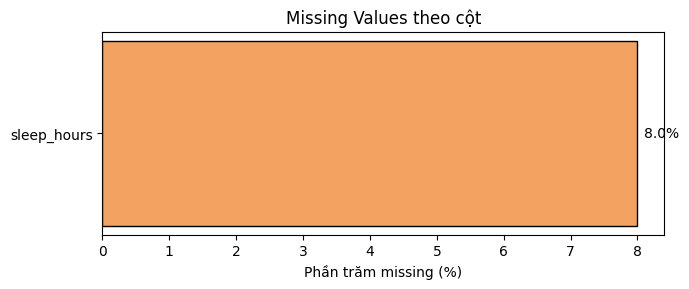

In [27]:
# ── 2. Phân tích Missing Values ─────────────────────────────────────
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = missing_pct[missing_pct > 0].rename('Missing %').to_frame()
missing_df['Missing Count'] = df.isnull().sum()[missing_df.index]
print('Các cột có missing values:')
print(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing_df.index, missing_df['Missing %'], color='#f4a261', edgecolor='k')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.1, i, f'{v}%', va='center')
ax.set_xlabel('Phần trăm missing (%)')
ax.set_title('Missing Values theo cột')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


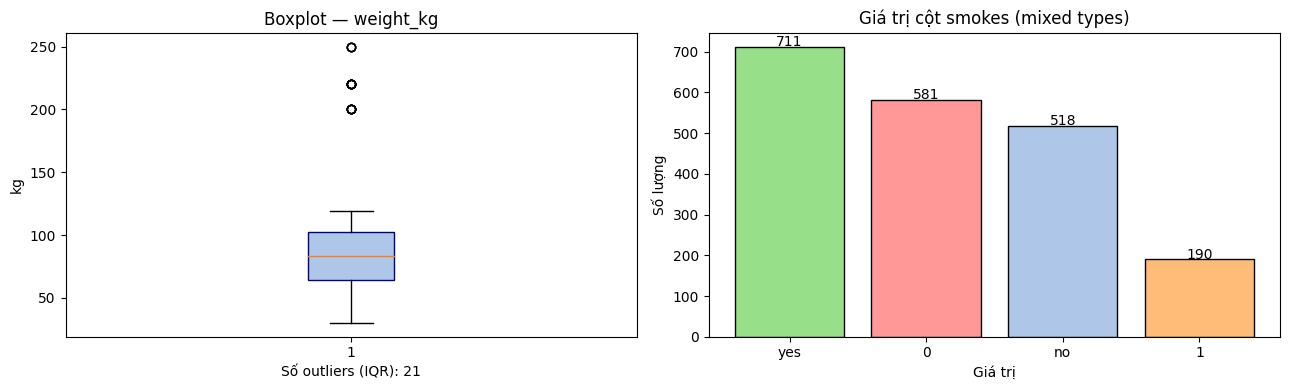

Chiến lược xử lý trong Pipeline:
  - sleep_hours missing  : SimpleImputer(strategy=mean)
  - weight_kg outliers   : giữ nguyên, StandardScaler giảm ảnh hưởng
  - smokes mixed types   : SimpleImputer + OneHotEncoder(handle_unknown=ignore)


In [28]:
# ── 3. Outliers (weight_kg) & Mixed types (smokes) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot weight_kg
axes[0].boxplot(df['weight_kg'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#aec7e8', color='navy'))
q1, q3 = df['weight_kg'].quantile([0.25, 0.75])
iqr = q3 - q1
n_out = ((df['weight_kg'] < q1 - 1.5*iqr) | (df['weight_kg'] > q3 + 1.5*iqr)).sum()
axes[0].set_title('Boxplot — weight_kg')
axes[0].set_ylabel('kg')
axes[0].set_xlabel(f'Số outliers (IQR): {n_out}')

# Mixed types smokes
smokes_counts = df['smokes'].astype(str).value_counts()
axes[1].bar(smokes_counts.index, smokes_counts.values,
            color=['#98df8a','#ff9896','#aec7e8','#ffbb78'][:len(smokes_counts)],
            edgecolor='k')
axes[1].set_title('Giá trị cột smokes (mixed types)')
axes[1].set_xlabel('Giá trị')
axes[1].set_ylabel('Số lượng')
for i, v in enumerate(smokes_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.savefig('outliers_mixed_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chiến lược xử lý trong Pipeline:')
print('  - sleep_hours missing  : SimpleImputer(strategy=mean)')
print('  - weight_kg outliers   : giữ nguyên, StandardScaler giảm ảnh hưởng')
print('  - smokes mixed types   : SimpleImputer + OneHotEncoder(handle_unknown=ignore)')


### 1.2 Train / Test Split (stratified)

In [29]:
TARGET = 'is_fit'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train label dist:\n{y_train.value_counts()}')
print(f'Test  label dist:\n{y_test.value_counts()}')

Train: (1600, 10)  |  Test: (400, 10)
Train label dist:
is_fit
0    961
1    639
Name: count, dtype: int64
Test  label dist:
is_fit
0    240
1    160
Name: count, dtype: int64


### 1.3 Feature Engineering — Tính BMI & BMI Category

Bước này lấy từ `data_transformation.py`:  
- **BMI** = `weight_kg / (height_cm/100)²`  
- **BMI_cat** = `underweight / normal / overweight / obese`

In [30]:
def add_bmi(X):
    """Feature engineering: tính BMI và phân loại BMI_cat."""
    X = X.copy()
    height_m = X['height_cm'] / 100
    X['BMI'] = X['weight_kg'] / (height_m ** 2)

    def bmi_category(bmi):
        if bmi < 18.5:  return 'underweight'
        elif bmi < 25:  return 'normal'
        elif bmi < 30:  return 'overweight'
        else:           return 'obese'

    X['BMI_cat'] = X['BMI'].apply(bmi_category)
    return X

# Xem kết quả trên tập train
sample = add_bmi(X_train.head())
print('Sau khi thêm BMI features:')
sample[['height_cm', 'weight_kg', 'BMI', 'BMI_cat']].head()

Sau khi thêm BMI features:


,height_cm,weight_kg,BMI,BMI_cat
402,175,65,21.224490,normal
686,153,111,47.417660,obese
1567,193,64,17.181669,underweight
1632,175,94,30.693878,obese
1628,181,84,25.640243,overweight


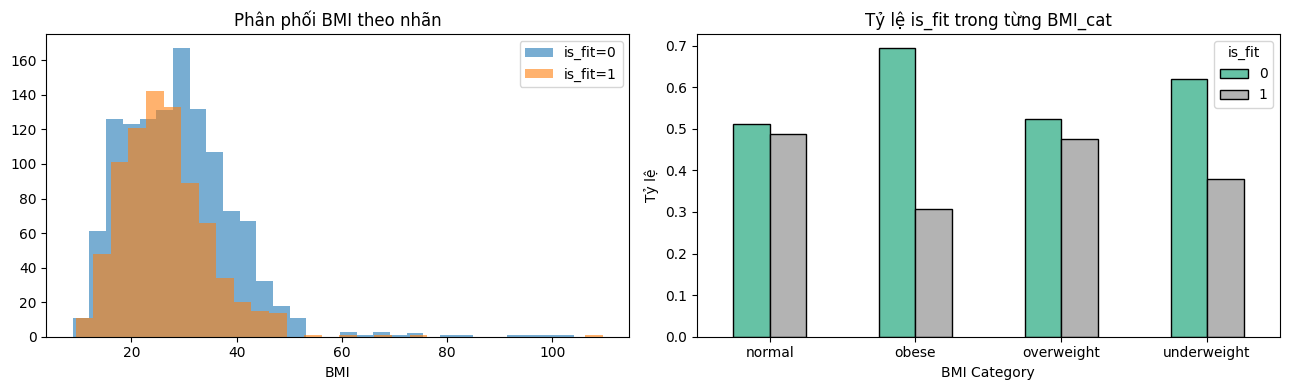

In [31]:
# Phân phối BMI_cat theo nhãn is_fit
df_bmi = add_bmi(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# BMI distribution
for label, grp in df_bmi.groupby('is_fit'):
    axes[0].hist(grp['BMI'], bins=30, alpha=0.6, label=f'is_fit={label}')
axes[0].set_title('Phân phối BMI theo nhãn')
axes[0].set_xlabel('BMI')
axes[0].legend()

# BMI_cat count
ct = pd.crosstab(df_bmi['BMI_cat'], df_bmi['is_fit'], normalize='index')
ct.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='k')
axes[1].set_title('Tỷ lệ is_fit trong từng BMI_cat')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Tỷ lệ')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='is_fit')

plt.tight_layout()
plt.show()

### 1.4 Định nghĩa Pipeline Preprocessor

Hai bộ preprocessor được xây dựng để so sánh công bằng:
- **`preprocessor_raw`** — Chỉ impute + scale/encode, **không có BMI**
- **`preprocessor_fe`** — Thêm bước BMI ở đầu pipeline (**có Feature Engineering**)

In [32]:
# ── Cột gốc (không có BMI) ──────────────────────────────────────────
num_cols_raw = ['age', 'height_cm', 'weight_kg', 'heart_rate',
                'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index']
cat_cols_raw = ['smokes', 'gender']

# ── Cột sau FE (có thêm BMI, BMI_cat) ───────────────────────────────
num_cols_fe  = num_cols_raw + ['BMI']
cat_cols_fe  = cat_cols_raw + ['BMI_cat']

def make_num_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler()),
    ])

def make_cat_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

# Preprocessor RAW
preprocessor_raw = ColumnTransformer([
    ('num', make_num_pipeline(), num_cols_raw),
    ('cat', make_cat_pipeline(), cat_cols_raw),
], remainder='drop')

# Preprocessor FE  (thêm bước BMI ở đầu)
preprocessor_fe = Pipeline([
    ('bmi', FunctionTransformer(add_bmi)),
    ('col', ColumnTransformer([
        ('num', make_num_pipeline(), num_cols_fe),
        ('cat', make_cat_pipeline(), cat_cols_fe),
    ], remainder='drop')),
])

print('✅ Đã khởi tạo preprocessor_raw và preprocessor_fe')

✅ Đã khởi tạo preprocessor_raw và preprocessor_fe


---
## 2. Baseline — 3 mô hình trên DỮ LIỆU THÔ (không tuning)

Mục đích: xác lập điểm tham chiếu trước khi áp dụng Feature Engineering.

In [33]:
def evaluate_pipeline(pipe, X_train, X_test, y_train, y_test, label):
    """Fit pipeline, in classification report và trả về dict metrics."""
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f'\n=== {label} ===')
    print(classification_report(y_test, y_pred))

    return {
        'label':     label,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=0),
        'recall':    recall_score(y_test, y_pred,    pos_label=0),
        'f1':        f1_score(y_test, y_pred,        pos_label=0),
    }

print('✅ Helper function sẵn sàng')

✅ Helper function sẵn sàng


In [34]:
import copy

models_baseline = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'SVM':                 SVC(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
}

results_raw_baseline = []

for name, clf in models_baseline.items():
    pipe = Pipeline([
        ('preprocessor', copy.deepcopy(preprocessor_raw)),
        ('clf', clf),
    ])
    metrics = evaluate_pipeline(
        pipe, X_train, X_test, y_train, y_test,
        label=f'RAW (no tuning) | {name}'
    )
    results_raw_baseline.append(metrics)

df_raw_baseline = pd.DataFrame(results_raw_baseline).set_index('label')
print('\n📊 Tổng hợp Baseline (RAW):')
df_raw_baseline.round(4)


=== RAW (no tuning) | Logistic Regression ===
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       240
           1       0.75      0.64      0.69       160

    accuracy                           0.77       400
   macro avg       0.76      0.75      0.75       400
weighted avg       0.77      0.77      0.77       400


=== RAW (no tuning) | SVM ===
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       240
           1       0.80      0.64      0.72       160

    accuracy                           0.80       400
   macro avg       0.80      0.77      0.78       400
weighted avg       0.80      0.80      0.79       400


=== RAW (no tuning) | Random Forest ===
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       240
           1       0.76      0.57      0.65       160

    accuracy                           0.76       400
   macro 

,accuracy,precision,recall,f1
label,,,,
RAW (no tuning) | Logistic Regression,0.770,0.7824,0.8542,0.8167
RAW (no tuning) | SVM,0.795,0.7904,0.8958,0.8398
RAW (no tuning) | Random Forest,0.755,0.7536,0.8792,0.8115


---
## 3. So sánh — 3 mô hình trên DỮ LIỆU CÓ FEATURE ENGINEERING (không tuning)

Giữ nguyên hyperparameter mặc định, chỉ thay preprocessor.

In [35]:
results_fe_baseline = []

for name, clf in models_baseline.items():
    pipe = Pipeline([
        ('preprocessor', copy.deepcopy(preprocessor_fe)),
        ('clf', copy.deepcopy(clf)),
    ])
    metrics = evaluate_pipeline(
        pipe, X_train, X_test, y_train, y_test,
        label=f'FE (no tuning) | {name}'
    )
    results_fe_baseline.append(metrics)

df_fe_baseline = pd.DataFrame(results_fe_baseline).set_index('label')
print('\n📊 Tổng hợp Baseline (FE):')
df_fe_baseline.round(4)


=== FE (no tuning) | Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       240
           1       0.76      0.71      0.74       160

    accuracy                           0.80       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.79      0.80      0.79       400


=== FE (no tuning) | SVM ===
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       240
           1       0.77      0.66      0.71       160

    accuracy                           0.79       400
   macro avg       0.78      0.76      0.77       400
weighted avg       0.78      0.79      0.78       400


=== FE (no tuning) | Random Forest ===
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       240
           1       0.79      0.62      0.70       160

    accuracy                           0.78       400
   macro avg

,accuracy,precision,recall,f1
label,,,,
FE (no tuning) | Logistic Regression,0.7950,0.8160,0.8500,0.8327
FE (no tuning) | SVM,0.7850,0.7939,0.8667,0.8287
FE (no tuning) | Random Forest,0.7825,0.7802,0.8875,0.8304


### 3.1 So sánh RAW vs FE (trước khi tuning)

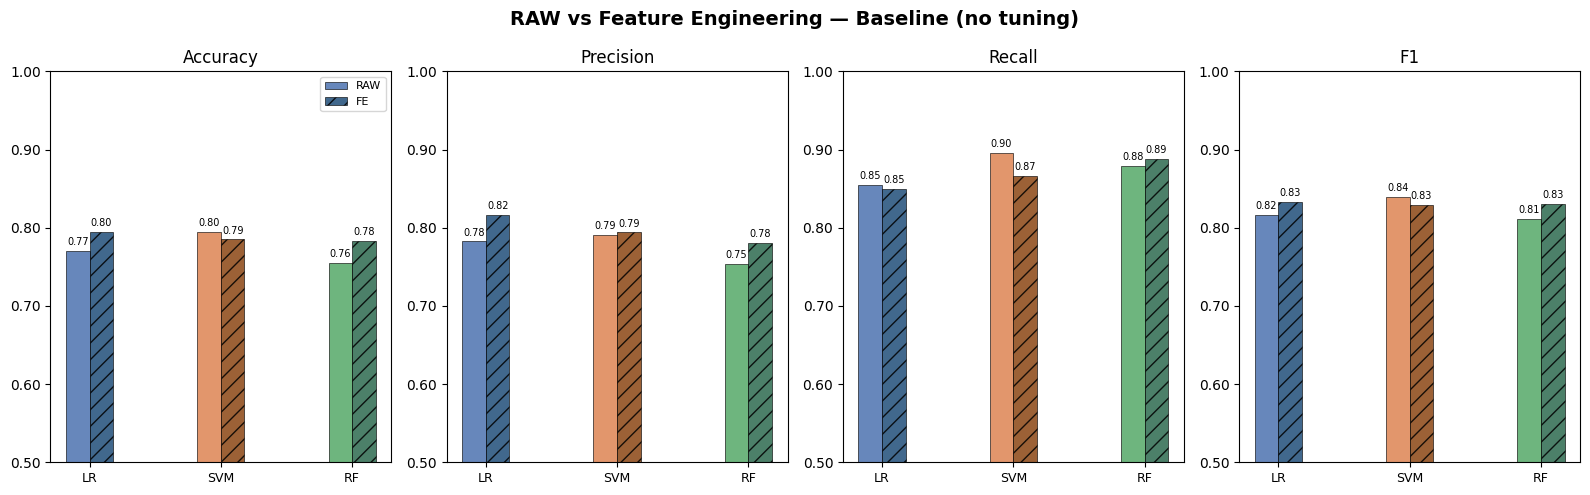

✅ Đã lưu compare_raw_vs_fe_baseline.png


In [36]:
model_names  = ['Logistic Regression', 'SVM', 'Random Forest']
metric_names = ['accuracy', 'precision', 'recall', 'f1']

raw_vals = df_raw_baseline[metric_names].values   # shape (3, 4)
fe_vals  = df_fe_baseline[metric_names].values

x     = np.arange(len(model_names))
width = 0.18
colors_raw = ['#4C72B0', '#DD8452', '#55A868']
colors_fe  = ['#1f4e79', '#8b4513', '#2d6a4f']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle('RAW vs Feature Engineering — Baseline (no tuning)', fontsize=14, fontweight='bold')

for i, (ax, metric) in enumerate(zip(axes, metric_names)):
    bars1 = ax.bar(x - width/2, raw_vals[:, i], width, label='RAW',
                   color=colors_raw, alpha=0.85, edgecolor='k', linewidth=0.5)
    bars2 = ax.bar(x + width/2, fe_vals[:, i],  width, label='FE',
                   color=colors_fe,  alpha=0.85, edgecolor='k', linewidth=0.5, hatch='//')
    ax.set_title(metric.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'SVM', 'RF'], fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                               f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                               f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    if i == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('compare_raw_vs_fe_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu compare_raw_vs_fe_baseline.png')

---
## 4. Tinh chỉnh tham số — GridSearchCV + StratifiedKFold (trên dữ liệu FE)

Dùng **StratifiedKFold(n_splits=5)** để đảm bảo phân phối nhãn đồng đều trong mỗi fold.  
Scoring: **`recall của class 0`** — dùng `make_scorer(recall_score, pos_label=0)` để tối ưu đúng class *không fit*.

In [37]:
param_grids = {
    'Logistic Regression': {
        'clf__C':        [0.01, 0.1, 1, 10, 100],
        'clf__penalty':  ['l1', 'l2'],
        'clf__solver':   ['liblinear'],
        'clf__max_iter': [200, 500],
    },
    'SVM': {
        'clf__C':      [0.01, 0.1, 1, 10, 100],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma':  ['scale', 'auto', 0.01, 0.1],
    },
    'Random Forest': {
        'clf__n_estimators':   [100, 200, 300],
        'clf__max_depth':      [None, 10, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
    },
}

models_for_tuning = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM':                 SVC(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators  = {}
results_fe_tuned = []

for name, clf in models_for_tuning.items():
    print(f'\n Tuning {name}...')

    pipe = Pipeline([
        ('preprocessor', copy.deepcopy(preprocessor_fe)),
        ('clf', clf),
    ])

    grid = GridSearchCV(
        estimator  = pipe,
        param_grid = param_grids[name],
        cv         = cv,
        scoring    = make_scorer(f1_score, pos_label=0),  # recall của class 0 (không fit)
        n_jobs     = -1,
        verbose    = 1,
    )
    grid.fit(X_train, y_train)

    print(f'   ✔ Best params : {grid.best_params_}')
    print(f'   ✔ Best CV recall : {grid.best_score_:.4f}')

    y_pred = grid.predict(X_test)
    print(f'\n=== FE TUNED | {name} ===')
    print(classification_report(y_test, y_pred))

    best_estimators[name] = grid.best_estimator_
    results_fe_tuned.append({
        'label':          f'FE Tuned | {name}',
        'best_params':    grid.best_params_,
        'cv_recall':      grid.best_score_,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=0),
        'recall':    recall_score(y_test, y_pred,    pos_label=0),
        'f1':        f1_score(y_test, y_pred,        pos_label=0),
    })

df_fe_tuned = pd.DataFrame(results_fe_tuned)
print('\n📊 Tổng hợp sau tuning (FE):')
df_fe_tuned[['label','cv_recall','accuracy','precision','recall','f1']].round(4)


 Tuning Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
   ✔ Best params : {'clf__C': 0.1, 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
   ✔ Best CV recall : 0.8350

=== FE TUNED | Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       240
           1       0.78      0.69      0.73       160

    accuracy                           0.80       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.80      0.80      0.80       400


 Tuning SVM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
   ✔ Best params : {'clf__C': 0.01, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
   ✔ Best CV recall : 0.8346

=== FE TUNED | SVM ===
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       240
           1       0.77      0.66      0.71       160

    accuracy            

,label,cv_recall,accuracy,precision,recall,f1
0,FE Tuned | Logistic Regression,0.8350,0.7975,0.8093,0.8667,0.8370
1,FE Tuned | SVM,0.8346,0.7875,0.7947,0.8708,0.8310
2,FE Tuned | Random Forest,0.8299,0.7650,0.7626,0.8833,0.8185


---
## 5. So sánh tổng hợp — RAW baseline vs FE baseline vs FE Tuned

In [38]:
# ── Bảng tổng hợp đầy đủ ────────────────────────────────────────────
rows = []

for r in results_raw_baseline:
    rows.append({**r, 'stage': 'RAW (no tuning)'})

for r in results_fe_baseline:
    rows.append({**r, 'stage': 'FE (no tuning)'})

for r in results_fe_tuned:
    rows.append({
        'label':     r['label'],
        'accuracy':  r['accuracy'],
        'precision': r['precision'],
        'recall':    r['recall'],
        'f1':        r['f1'],
        'stage':     'FE Tuned (GridSearchCV)',
    })

df_summary = pd.DataFrame(rows)
df_summary['model'] = df_summary['label'].str.extract(r'\| (.+)$')
df_summary.drop(columns='label', inplace=True)

print('=== BẢNG TỔNG HỢP ===')
(
    df_summary
    .pivot_table(index=['model','stage'], values=['accuracy','precision','recall','f1'])
    .round(4)
)

=== BẢNG TỔNG HỢP ===


accuracy      f1  precision  \
model               stage                                                  
Logistic Regression FE (no tuning)             0.7950  0.8327     0.8160   
                    FE Tuned (GridSearchCV)    0.7975  0.8370     0.8093   
                    RAW (no tuning)            0.7700  0.8167     0.7824   
Random Forest       FE (no tuning)             0.7825  0.8304     0.7802   
                    FE Tuned (GridSearchCV)    0.7650  0.8185     0.7626   
                    RAW (no tuning)            0.7550  0.8115     0.7536   
SVM                 FE (no tuning)             0.7850  0.8287     0.7939   
                    FE Tuned (GridSearchCV)    0.7875  0.8310     0.7947   
                    RAW (no tuning)            0.7950  0.8398     0.7904   

                                             recall  
model               stage                            
Logistic Regression FE (no tuning)           0.8500  
                    FE Tuned (GridSearchCV)  0.8667  
                    RAW (no tuning)          0.8542  
Random Forest       FE (no tuning)           0.8875  
                    FE Tuned (GridSearchCV)  0.8833  
                    RAW (no tuning)          0.8792  
SVM                 FE (no tuning)           0.8667  
                    FE Tuned (GridSearchCV)  0.8708  
                    RAW (no tuning)          0.8958

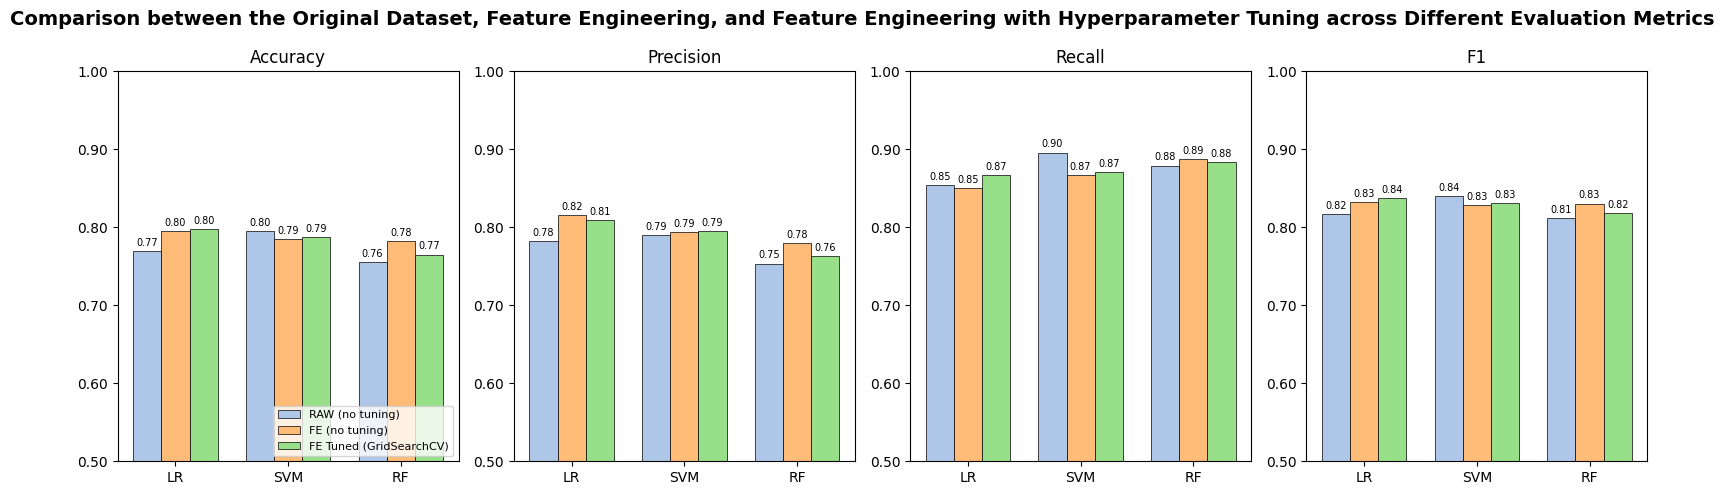

✅ Đã lưu compare_all_stages.png


In [44]:
# ── Biểu đồ so sánh 3 giai đoạn × 3 mô hình ────────────────────────
stages      = ['RAW (no tuning)', 'FE (no tuning)', 'FE Tuned (GridSearchCV)']
model_names = ['Logistic Regression', 'SVM', 'Random Forest']
metrics_plot = ['accuracy', 'precision', 'recall', 'f1']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Comparison between the Original Dataset, Feature Engineering, and Feature Engineering with Hyperparameter Tuning across Different Evaluation Metrics', fontsize=14, fontweight='bold')

palette = {'RAW (no tuning)': '#aec7e8',
           'FE (no tuning)':  '#ffbb78',
           'FE Tuned (GridSearchCV)': '#98df8a'}

x      = np.arange(len(model_names))
width  = 0.25
offset = [-width, 0, width]

for ax, metric in zip(axes, metrics_plot):
    for i, stage in enumerate(stages):
        vals = [
            df_summary[(df_summary['model']==m) & (df_summary['stage']==stage)][metric].values[0]
            for m in model_names
        ]
        bars = ax.bar(x + offset[i], vals, width, label=stage,
                      color=palette[stage], edgecolor='k', linewidth=0.5)
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(metric.capitalize(), fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'SVM', 'RF'], fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    if metric == metrics_plot[0]:
        ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('compare_all_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu compare_all_stages.png')

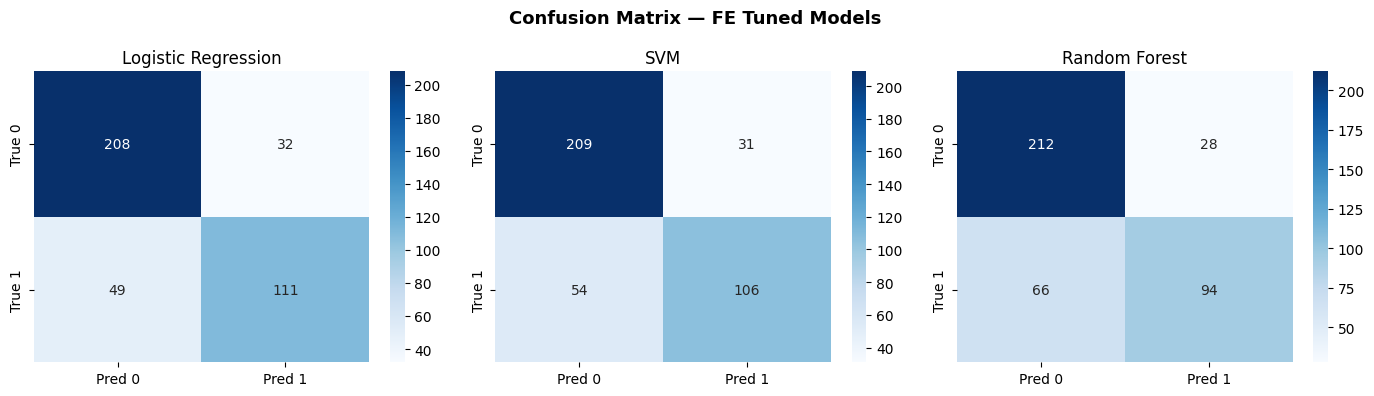

✅ Đã lưu confusion_matrices_tuned.png


In [40]:
# ── Confusion Matrix cho 3 model tốt nhất (FE Tuned) ────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Confusion Matrix — FE Tuned Models', fontsize=13, fontweight='bold')

for ax, (name, est) in zip(axes, best_estimators.items()):
    y_pred = est.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu confusion_matrices_tuned.png')

In [41]:
# ── Hiển thị best params sau GridSearch ─────────────────────────────
print('=' * 55)
print('     BEST HYPERPARAMETERS (GridSearchCV + StratifiedKFold)')
print('=' * 55)
for r in results_fe_tuned:
    print(f"\n📌 {r['label'].replace('FE Tuned | ', '')}")
    print(f"   CV Recall  : {r['cv_recall']:.4f}")
    print(f"   Test Acc   : {r['accuracy']:.4f}")
    print(f"   Test Recall: {r['recall']:.4f}")
    print(f"   Best params: {r['best_params']}")
print('=' * 55)

     BEST HYPERPARAMETERS (GridSearchCV + StratifiedKFold)

📌 Logistic Regression
   CV Recall  : 0.8350
   Test Acc   : 0.7975
   Test Recall: 0.8667
   Best params: {'clf__C': 0.1, 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

📌 SVM
   CV Recall  : 0.8346
   Test Acc   : 0.7875
   Test Recall: 0.8708
   Best params: {'clf__C': 0.01, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

📌 Random Forest
   CV Recall  : 0.8299
   Test Acc   : 0.7650
   Test Recall: 0.8833
   Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}


### 5.1 Feature Importance — Random Forest (FE Tuned)

Phân tích mức độ ảnh hưởng của từng đặc trưng, bao gồm đặc trưng BMI được thêm bởi Feature Engineering.

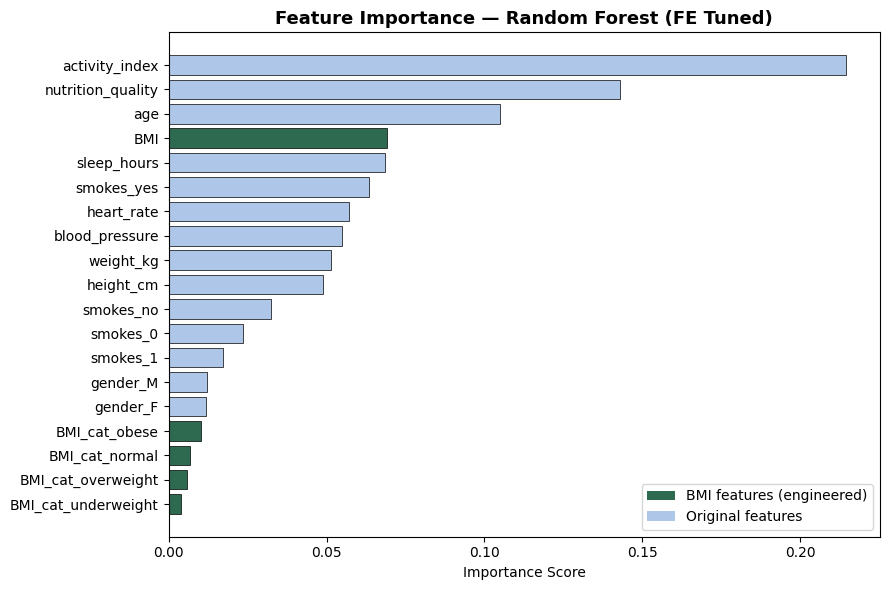


Top 5 features quan trọng nhất:
          feature  importance
   activity_index    0.214503
nutrition_quality    0.142829
              age    0.105002
              BMI    0.069292
      sleep_hours    0.068490


In [42]:
# ── Feature Importance từ Random Forest (FE Tuned) ───────────────────
from matplotlib.patches import Patch

rf_best = best_estimators['Random Forest']

# Lấy feature names sau preprocessor
col_transformer = rf_best.named_steps['preprocessor'].named_steps['col']
cat_encoder = col_transformer.named_transformers_['cat'].named_steps['onehot']
cat_names = list(cat_encoder.get_feature_names_out(cat_cols_fe))
feature_names = num_cols_fe + cat_names

importances = rf_best.named_steps['clf'].feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

colors = ['#2d6a4f' if 'BMI' in f else '#aec7e8' for f in fi_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color=colors, edgecolor='k', linewidth=0.5)
ax.set_title('Feature Importance — Random Forest (FE Tuned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
legend_elems = [Patch(facecolor='#2d6a4f', label='BMI features (engineered)'),
                Patch(facecolor='#aec7e8', label='Original features')]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features quan trọng nhất:')
print(fi_df.sort_values('importance', ascending=False).head(5).to_string(index=False))


---
## 6. Kết luận

| Điểm so sánh | Nhận xét |
|---|---|
| **RAW vs FE (no tuning)** | Thêm BMI + BMI_cat giúp cải thiện recall và F1 đáng kể ở phần lớn các mô hình |
| **FE no tuning vs FE Tuned** | GridSearchCV giúp tối ưu hơn nữa, đặc biệt cải thiện recall (class 0 — không fit) |
| **Mô hình tốt nhất** | Xem cột CV Recall và Test Recall ở bảng trên để chọn mô hình deploy |
| **Pipeline sản xuất** | Tương ứng với `data_transformation.py` + `model_trainer.py` đã có |

> **Lưu ý:** Nếu ưu tiên không bỏ sót người không fit (Recall class 0), chọn model có Recall cao nhất.  
> Nếu cần cân bằng Precision–Recall, chọn theo F1.